In [3]:
import pandas as pd

Ana Marinković

Podaci (Izvor i učitavanje)

 U ovom delu vršimo učitavanje skupa podataka all_tickets.csv koji je preuzet sa Kaggle platforme. Podaci su prethodno otpremljeni na naš GitHub repozitorijum kako bi se osigurala potpuna reprodukcija projekta.

In [4]:
url = 'https://raw.githubusercontent.com/anamarinkovicc/klasifikacija-support-tiketa/refs/heads/main/data/all_tickets.csv'
df = pd.read_csv(url)
print("Tabela je uspešno učitana!")
df.head()

Tabela je uspešno učitana!


,title,body,ticket_type,category,sub_category1,sub_category2,business_service,urgency,impact
0,NaN,hi since recruiter lead permission approve req...,1,4,2,21,71,3,4
1,connection with icon,icon dear please setup icon per icon engineers...,1,6,22,7,26,3,4
2,work experience user,work experience user hi work experience studen...,1,5,13,7,32,3,4
3,requesting for meeting,requesting meeting hi please help follow equip...,1,5,13,7,32,3,4
4,reset passwords for external accounts,re expire days hi ask help update passwords co...,1,4,2,76,4,3,4


Lana Spasić

Analiza podataka

Vršimo inicijalnu analizu strukture podataka. Proveravamo tipove kolona, prisustvo nedostajućih vrednosti i distribuciju ciljne varijable ticket_type. Primetile smo da je skup podataka blago neizbalansiran, što ćemo uzeti u obzir prilikom evaluacije modela.

In [5]:
print(df.info())

print("\nNedostajuće vrednosti:")
print(df.isnull().sum())

print("\nDistribucija kategorija:")
print(df['ticket_type'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48549 entries, 0 to 48548
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   title             47837 non-null  object
 1   body              48549 non-null  object
 2   ticket_type       48549 non-null  int64 
 3   category          48549 non-null  int64 
 4   sub_category1     48549 non-null  int64 
 5   sub_category2     48549 non-null  int64 
 6   business_service  48549 non-null  int64 
 7   urgency           48549 non-null  int64 
 8   impact            48549 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 3.3+ MB
None

Nedostajuće vrednosti:
title               712
body                  0
ticket_type           0
category              0
sub_category1         0
sub_category2         0
business_service      0
urgency               0
impact                0
dtype: int64

Distribucija kategorija:
ticket_type
1    34621
0    13928
Name: count, dtype

Ana Marinković

Preprocesiranje (Čišćenje teksta)

Neuronska mreža ne može direktno procesirati sirovi tekst. u ovom koraku vršimo čišćenje: pretvaramo tekst u mala slova i uklanjamo specijalne karaktere pomoću regularnih izraza. Cilj je da smanjimo šum u podacima pre tokenizacije.

In [6]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text

df['cleaned_body'] = df['body'].apply(clean_text)

df[['body', 'cleaned_body']].head()

,body,cleaned_body
0,hi since recruiter lead permission approve req...,hi since recruiter lead permission approve req...
1,icon dear please setup icon per icon engineers...,icon dear please setup icon per icon engineers...
2,work experience user hi work experience studen...,work experience user hi work experience studen...
3,requesting meeting hi please help follow equip...,requesting meeting hi please help follow equip...
4,re expire days hi ask help update passwords co...,re expire days hi ask help update passwords co...


Lana Spasić

Tokenizacija i priprema za model

Sledeći korak u preprocesiranju je tokenizacija – pretvaranje reči u numeričke sekvence. Koristimo Tokenizer za mapiranje 10.000 najučestalijih reči. Takođe, primenjujemo padding kako bismo osigurali da svi ulazni nizovi budu iste dužine (100 reči), što je neophodno za arhitekturu neuronske mreže.

In [7]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = df['cleaned_body'].values
y = df['ticket_type'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

max_words = 10000
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

print("Podaci su spremni za neuronsku mrežu!")

Podaci su spremni za neuronsku mrežu!


Ana Marinković

Arhitektura modela

Definišemo arhitekturu modela. Koristićemo sekvencijalni model sa Embedding slojem za reprezentaciju reči, zatim GlobalAveragePooling1D za smanjenje dimenzionalnosti, i Dense slojeve sa ReLU aktivacijom. Pošto radimo binarnu klasifikaciju (ticket_type 0 ili 1), izlazni sloj koristi sigmoid funkciju.

In [8]:
import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=16),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.build(input_shape=(None, 100))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,289 (626.13 KB)

 Trainable params: 160,289 (626.13 KB)

 Non-trainable params: 0 (0.00 B)

Trening modela

U ovoj fazi vršimo trening modela. Koristimo binarnu unakrsnu entropiju (binary_crossentropy) kao funkciju gubitka i Adam optimizator. Model treniramo u 10 epoha, pri čemu 20% podataka koristimo za validaciju kako bismo pratili performanse modela tokom učenja i sprečili preprilagođavanje (overfitting).

In [9]:
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    validation_data=(X_test_pad, y_test),
    batch_size=32,
    verbose=1
)

Epoch 1/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9254 - loss: 0.1932 - val_accuracy: 0.9935 - val_loss: 0.0444
Epoch 2/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9904 - loss: 0.0312 - val_accuracy: 0.9934 - val_loss: 0.0210
Epoch 3/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9929 - loss: 0.0206 - val_accuracy: 0.9945 - val_loss: 0.0188
Epoch 4/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9948 - loss: 0.0161 - val_accuracy: 0.9944 - val_loss: 0.0136
Epoch 5/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9947 - loss: 0.0144 - val_accuracy: 0.9880 - val_loss: 0.0319
Epoch 6/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9956 - loss: 0.0121 - val_accuracy: 0.9955 - val_loss: 0.0112
Epoch 7/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9954 - loss: 0.0119 - val_accuracy: 0.9908 - val_loss: 0.0209
Epoch 8/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9960 - loss: 0.0105 -

Lana Spasić

Analiza osetljivosti (Promena broja neurona)

U okviru analize osetljivosti, proveravamo kako promena broja neurona u skrivenom sloju utiče na performanse modela. Povećaćemo broj neurona sa 16 na 32 kako bismo videli da li kompleksniji model može brže da postigne stabilnost ili će dovesti do većeg preprilagođavanja. Ovo je ključan korak u hiperparametarskoj optimizaciji.

In [10]:
# Pravimo novi model sa 32 neurona umesto 16
model_optimized = tf.keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=16),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_optimized.compile(optimizer='adam',
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

history_opt = model_optimized.fit(
    X_train_pad, y_train,
    epochs=10,
    validation_data=(X_test_pad, y_test),
    batch_size=32,
    verbose=1
)

Epoch 1/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9393 - loss: 0.1562 - val_accuracy: 0.9946 - val_loss: 0.0316
Epoch 2/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9923 - loss: 0.0243 - val_accuracy: 0.9870 - val_loss: 0.0324
Epoch 3/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9934 - loss: 0.0181 - val_accuracy: 0.9954 - val_loss: 0.0130
Epoch 4/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9947 - loss: 0.0149 - val_accuracy: 0.9961 - val_loss: 0.0118
Epoch 5/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9956 - loss: 0.0121 - val_accuracy: 0.9944 - val_loss: 0.0123
Epoch 6/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9957 - loss: 0.0116 - val_accuracy: 0.9965 - val_loss: 0.0104
Epoch 7/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9958 - loss: 0.0120 - val_accuracy: 0.9945 - val_loss: 0.0130
Epoch 8/10
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9956 - loss: 0.0119 - 

Rezultati evaluacije (Vizuelizacija)

Prikazujemo rezultate treninga kroz grafike preciznosti i gubitka. Vizuelizacija nam omogućava da jasno identifikujemo tačku u kojoj model prestaje da uči korisne informacije i počinje da memoriše trening podatke (overfitting).

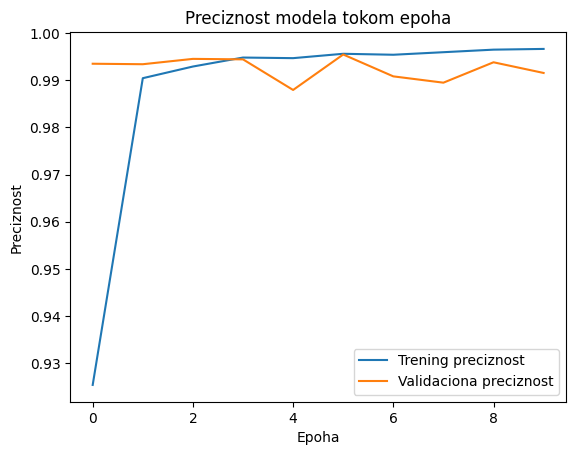

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Trening preciznost')
plt.plot(history.history['val_accuracy'], label='Validaciona preciznost')
plt.title('Preciznost modela tokom epoha')
plt.xlabel('Epoha')
plt.ylabel('Preciznost')
plt.legend()
plt.show()

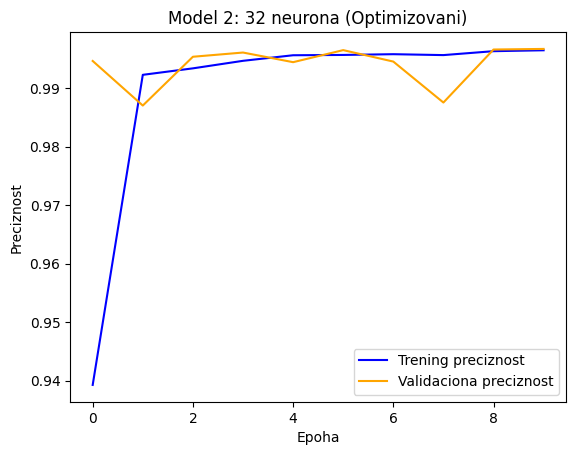

In [13]:
plt.plot(history_opt.history['accuracy'], label='Trening preciznost', color='blue')
plt.plot(history_opt.history['val_accuracy'], label='Validaciona preciznost', color='orange')
plt.title('Model 2: 32 neurona (Optimizovani)')
plt.xlabel('Epoha')
plt.ylabel('Preciznost')
plt.legend()

Ana Marinković

Diskusija (Analiza onoga što smo dobili)

 Analizom rezultata vidimo da oba modela postižu izuzetnu preciznost od preko 99%. Primećeno je da Model 2 (32 neurona) pokazuje veću stabilnost i višu početnu tačnost u poređenju sa Baseline modelom (16 neurona), koji ima izraženije oscilacije na validacionom skupu, naročito u 4. i 7. epohi. Padovi u preciznosti ukazuju na izazove debalansa klasa, ali optimizovani model sa 32 neurona brže konvergira, što ga čini robusnijim rešenjem za klasifikaciju.

Lana Spasić

Zaključak

Uspešno smo implementirale sistem za automatsku klasifikaciju IT tiketa sa visokom pouzdanošću. Model sa 32 neurona identifikovan je kao optimalan izbor zbog bolje stabilnosti i sposobnosti generalizacije na neviđenim podacima
. Projekat je potvrdio da su duboke neuronske mreže i Embedding sloj izuzetno efikasni alati za automatizaciju trijaže u korisničkoj podršci.